In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
from scipy.special import kl_div

In [2]:
jades_data = pd.read_csv("data/jades_dr5_photometric_catalog_subset.csv").drop("Unnamed: 0", axis="columns")

In [3]:
jades_data

,F090W_KRON,F115W_KRON,F150W_KRON,F182M_KRON,F200W_KRON,F277W_KRON,F335M_KRON,F356W_KRON,F410M_KRON,F435W_KRON,...,F814W_KRON,F850LP_KRON,F125W_KRON,F140W_KRON,F160W_KRON,Q,R_KRON,unscaled_F444W_KRON,ID,photoz
0,0.386780,0.300087,0.633389,1.255446,0.623497,0.876420,0.909183,0.886891,1.136959,0.299658,...,0.728978,0.487159,0.888711,-0.537893,0.693334,0.390726,0.745056,116.064542,490,2.80
1,1.760779,2.398820,1.858198,1.308508,1.686628,1.652174,1.775756,1.824354,0.883753,1.589711,...,1.974697,2.307263,2.268095,0.739194,1.037109,0.915636,0.326000,25.601965,519,0.76
2,-0.869462,0.835223,0.112352,1.001784,0.545806,1.268684,1.460337,1.533824,0.732482,-0.230372,...,0.287732,0.086536,-0.079786,1.770051,1.758321,0.954687,0.509296,30.149901,522,3.49
3,1.173474,0.947350,1.528584,1.542125,1.162309,1.234815,1.141565,1.110963,1.376555,1.168281,...,0.547270,0.725842,1.058812,0.827280,2.331888,0.544861,0.420613,89.744492,549,2.42
4,1.688582,1.449304,1.279279,2.667931,1.834312,1.253783,1.194935,1.174235,1.060439,0.431678,...,1.587199,4.443156,2.505961,1.790643,4.172483,0.860860,0.421539,28.120277,550,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89725,-0.090871,0.080197,0.138278,0.184751,0.043777,0.056973,0.094905,0.109284,0.557477,-0.447143,...,-0.025884,0.722157,0.044524,0.266411,0.031988,0.743172,0.244562,26.270901,3301718,8.61
89726,0.454743,0.371896,-0.101835,-0.975059,0.115758,0.154993,0.673163,0.116752,0.328982,-0.699361,...,0.156044,-0.727166,0.048787,1.411943,0.003833,0.560676,0.395464,41.189591,3301754,4.99
89727,-0.695332,-0.328651,-0.470085,-0.029591,0.133646,0.299675,-0.168792,-0.478896,-0.248164,-0.014939,...,0.065822,-0.073610,-0.091850,0.616456,0.829263,0.896412,0.422729,33.786540,3301987,4.22
89728,0.477811,0.263739,-0.168404,0.547131,0.541751,-0.017597,-0.128883,0.163685,0.952204,1.251010,...,-0.195149,0.323955,0.737724,-0.032473,0.553756,0.730629,0.267007,20.080720,3302027,17.30


In [4]:
F277W_KRON = jades_data["F277W_KRON"].values

# Testing for outliers

## Possible methods to determine outliers:

1) Outliers are points greater than *x* sigma away from the median.

    a) Calculate the median of the distribution:
    
    `median = np.median(dist)`

    b) Calculate the standard deviation of the distribution centered at the median:
    
    `stddev = np.std(dist, mean=median)`

    c) Choose a value of sigma (e.g. `7`) outside of which to consider each value an outlier: 

    `upper_outliers =  dist > upper_bound`

    `lower_outliers =  dist < lower_bound`

2) k-Nearest Neighbors approach:

    a) Use https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html#sklearn.neighbors.LocalOutlierFactor.

If the distribution is multimodal, a Gaussian around the median is a bad representation of the data, so the sigma approach will remove points asymmetrically at the extremes of the distribution.

## Possible ways to treat outliers once identified:

If outliers are identified via the sigma approach:

1) Assign all values above the upper bound to the upper bound's value, and all values below the lower bound to the lower bound's value:

`dist_modified = np.copy(dist)`

`dist_modified[upper_outliers] = upper_bound`

`dist_modified[lower_outliers] = lower_bound`

2) Mask out all values above the upper bound and below the lower bound:

`dist_modified = np.copy(dist)`

`dist_modified = dist_modified[~upper_outliers & ~lower_outliers]`

In [ ]:
# # Source - https://stackoverflow.com/a/29222992
# # Posted by sergeyf, modified by community. See post 'Timeline' for change history
# # Retrieved 2026-06-23, License - CC BY-SA 3.0

# def doubleMADsfromMedian(y,thresh=5):

#     # warning: this function does not check for NAs
#     # nor does it address issues when 
#     # more than 50% of your data have identical values

#     m = np.median(y)
#     abs_dev = np.abs(y - m)
#     left_mad = np.median(abs_dev[y <= m])
#     right_mad = np.median(abs_dev[y >= m])
#     y_mad = left_mad * np.ones(len(y))
#     y_mad[y > m] = right_mad
#     modified_z_score = 0.6745 * abs_dev / y_mad
#     modified_z_score[y == m] = 0

#     return modified_z_score > thresh

# def handle_outliers(dist, method='sigma', treatment='reassign', sigma_value=7, thresh=5, n_neighbors=20):
#     """
#     Function to identify and handle outlier values in the distribution,
#     which would drastically change the scaling of the colorbar if not addressed.

#     Inputs
#     -------
#     dist: 1d float array
#         data to be represented by the colorbar.
#     method: str, default='sigma'
#         the method to use to identify outliers. options are 'sigma', 'double_mad', and 'knn'.
#     treatment: str, default='reassign'
#         how to treat the identified outliers. options are 'reassign' and 'mask_out'.
#     sigma_value: int, default 7
#         number of stddev to use when identifying outliers, if using the sigma method.
#     thresh: float, default 5
#     n_neighbors: int, default 20
#         number of nearest neighbors to consider, if using the knn method.
    
#     Outputs
#     -------
#     modified_dist: 1d float array
#         data to be represented by the colorbar, treated for outliers according to the specifications.
#     """

#     # choose the method to determine outliers

#     if method == 'sigma':
        
#         median = np.median(dist)
#         # center the gaussian at the median of the distribution
#         stddev = np.std(dist, mean=median)

#         lower_bound = median - sigma_value * stddev
#         upper_bound = median + sigma_value * stddev

#         # choose the method to treat outliers

#         if treatment == 'reassign':

#             # make a deep copy
#             dist_modified = np.copy(dist)
#             dist_modified[upper_outliers] = upper_bound
#             dist_modified[lower_outliers] = lower_bound

#         elif treatment == 'mask_out':

#             dist_modified = dist[~upper_outliers & ~lower_outliers]

#     elif method == 'double_mad':

#         outlier_mask = doubleMADsfromMedian(dist, thresh=5)

#         # choose the method to treat outliers

#         if treatment == 'reassign':

#             # make a deep copy
#             dist_modified = np.copy(dist)

#             upper_vals = dist > np.median()
#             dist_modified[outlier_mask] = upper_bound
#             dist_modified[lower_outliers] = lower_bound

#         elif treatment == 'mask_out':

#             dist_modified = dist[~upper_outliers & ~lower_outliers]

#     elif method == 'knn':

#         lof = LocalOutlierFactor(n_neighbors=n_neighbors)
#         outliers = lof.fit_predict(dist)
        

#     return dist_modified
    

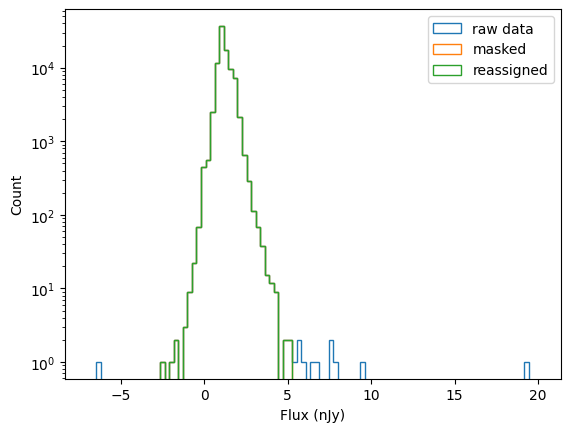

In [14]:
from outliers import handle_outliers

# test this function
F277W_KRON_modified = handle_outliers(F277W_KRON, sigma_value=10, treatment='mask_out')

plt.hist(F277W_KRON, bins=np.linspace(-7,20,100), label='raw data', histtype='step')
plt.hist(F277W_KRON_modified, bins=np.linspace(-7,20,100), label='masked', histtype='step')
plt.hist(F277W_KRON_modified, bins=np.linspace(-7,20,100), label='reassigned', histtype='step')
plt.yscale('log')
plt.xlabel('Flux (nJy)')
plt.ylabel('Count')
plt.legend()
plt.show()

# Testing for models